     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 84.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.3/15.3 MB 66.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.9/53.9 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 59.2 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('ru_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Загрузка текстов...
Семантическое выравнивание...
Вычисление метрик...


Анализ (Пастернак): 100%|██████████| 3682/3682 [01:02<00:00, 59.34it/s]


Оригинал             Перевод          
Переводчик           Лозинский Пастернак Лозинский Пастернак
Метрика                                                     
POS-дивергенция            NaN       NaN     1.046     1.096
Валентность глаголов     0.539     0.536     0.497     0.423
Инверсий на строку       0.014     0.015     0.084     0.087
Косинусное сходство        NaN       NaN     0.730     0.718
Плотность пунктуации     0.422     0.425     0.282     0.286
Среднее число слогов     8.743     8.734     9.094     9.001
Средняя длина строки     6.617     6.609     4.681     4.470

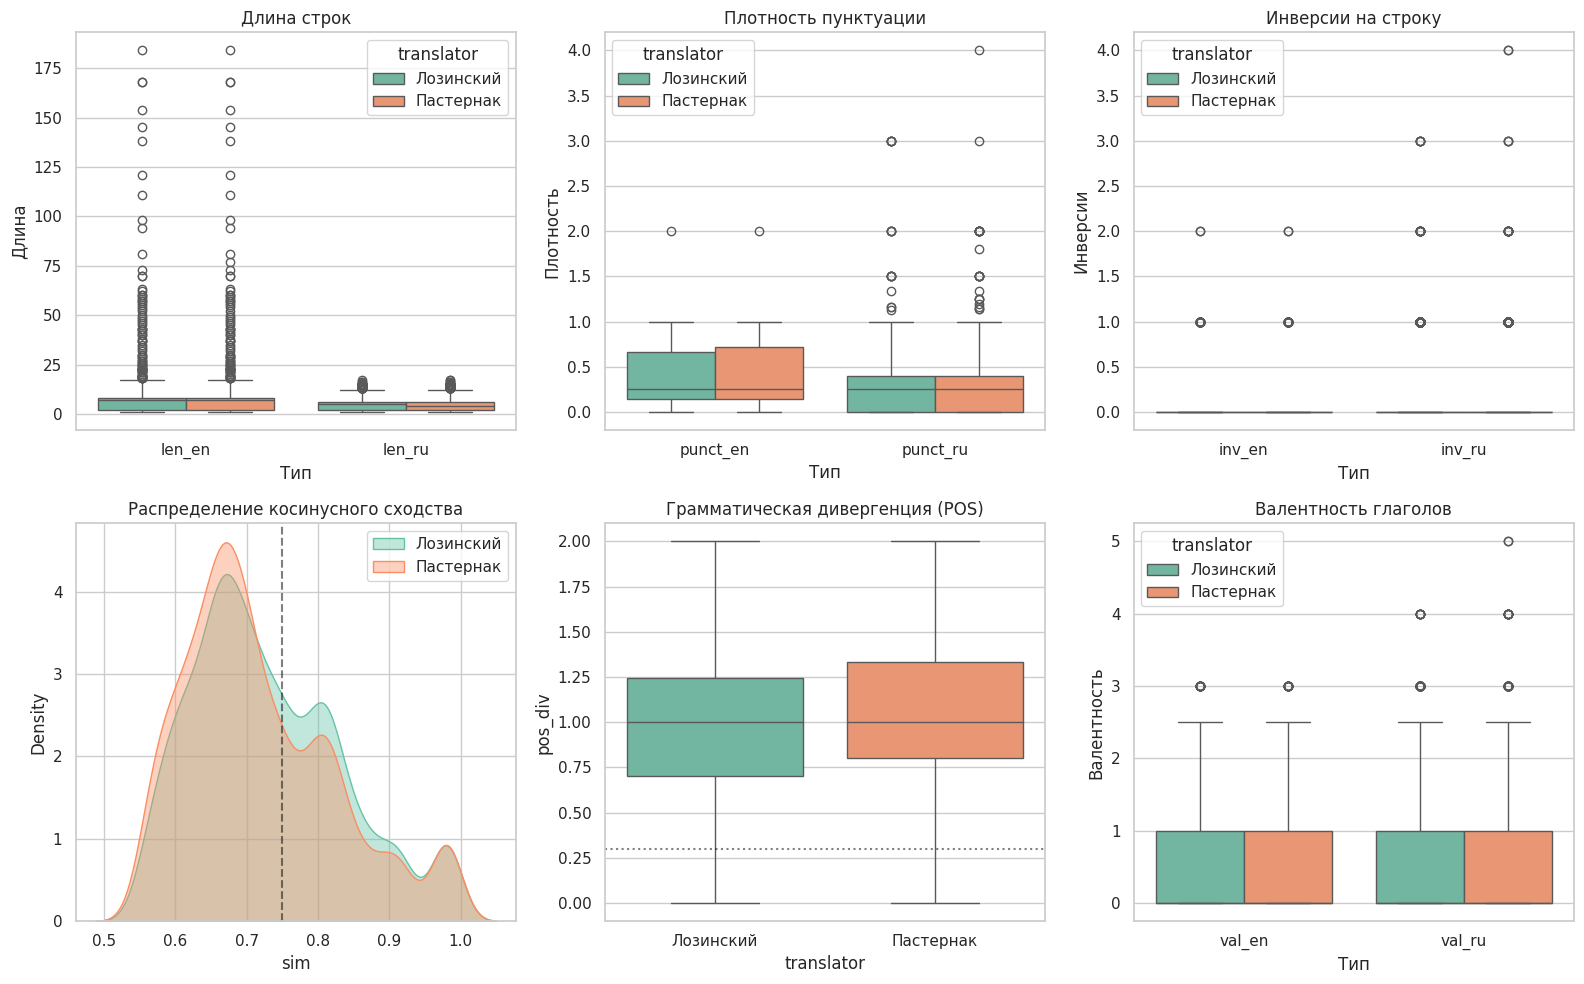

Анализ завершён. Данные сохранены.


In [1]:
!pip install -q spacy sentence-transformers syllapy pandas numpy scipy seaborn matplotlib tqdm
!python -m spacy download en_core_web_sm
!python -m spacy download ru_core_news_sm

import pandas as pd
import numpy as np
import spacy
import re
import string
import syllapy
from tqdm import tqdm
from sentence_transformers import SentenceTransformer, util
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import linear_sum_assignment
from IPython.display import display, HTML
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="Set2")

nlp_en = spacy.load("en_core_web_sm")
nlp_ru = spacy.load("ru_core_news_sm")
model_emb = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

def load_and_clean(path):
    with open(path, 'r', encoding='utf-8') as f:
        text = f.read()
    text = re.sub(r'\[.*?\]|\(.*?\)|\{.*?\}', '', text)
    return [l.strip() for l in text.split('\n') if len(l.strip()) >= 3]

def count_syllables(word, lang='auto'):
    word = word.lower().strip(string.punctuation + '«»""\'')
    if not word: return 0
    if lang == 'ru' or any('\u0400' <= c <= '\u04FF' for c in word):
        vowels = 'аеёиоуыэюя'
        return max(1, sum(1 for c in word if c in vowels))
    else:
        try: return max(1, syllapy.count(word))
        except:
            vowels = 'aeiouy'
            return max(1, sum(1 for c in word if c in vowels))

def detect_inversions(doc):
    inv = 0
    for token in doc:
        if token.dep_ in ('nsubj', 'nsubjpass') and token.i > token.head.i and token.head.pos_ == 'VERB':
            inv += 1
    return inv

def get_pos_distribution(doc):
    pos_counts = {}
    for token in doc:
        pos_counts[token.pos_] = pos_counts.get(token.pos_, 0) + 1
    total = sum(pos_counts.values()) or 1
    return {k: v/total for k, v in pos_counts.items()}

def pos_l1_distance(dist1, dist2):
    all_tags = set(list(dist1.keys()) + list(dist2.keys()))
    return sum(abs(dist1.get(t, 0) - dist2.get(t, 0)) for t in all_tags)

def calc_valency(doc):
    verbs = [t for t in doc if t.pos_ == 'VERB']
    if not verbs: return 0
    args = sum(len([c for c in v.children if c.dep_ in ('nsubj', 'dobj', 'iobj', 'pobj', 'obj', 'attr')]) for v in verbs)
    return args / len(verbs)

def align_texts(lines_a, lines_b, model, threshold=0.55):
    emb_a = model.encode(lines_a, convert_to_tensor=True, batch_size=64, show_progress_bar=False)
    emb_b = model.encode(lines_b, convert_to_tensor=True, batch_size=64, show_progress_bar=False)
    sim_matrix = util.pytorch_cos_sim(emb_a, emb_b).cpu().numpy()
    row_ind, col_ind = linear_sum_assignment(-sim_matrix)
    aligned = []
    for i, j in zip(row_ind, col_ind):
        score = sim_matrix[i, j]
        if score >= threshold:
            aligned.append((lines_a[i], lines_b[j], score))
    return aligned

def compute_metrics(aligned_pairs, nlp_en, nlp_ru, translator_name):
    data = []
    for en, ru, sim in tqdm(aligned_pairs, desc=f"Анализ ({translator_name})"):
        doc_en, doc_ru = nlp_en(en), nlp_ru(ru)
        pos_en = get_pos_distribution(doc_en)
        pos_ru = get_pos_distribution(doc_ru)
        data.append({
            'translator': translator_name,
            'len_en': len(en.split()),
            'len_ru': len(ru.split()),
            'punct_en': sum(1 for c in en if c in string.punctuation + '«»""\'') / max(len(en.split()), 1),
            'punct_ru': sum(1 for c in ru if c in string.punctuation + '«»""\'') / max(len(ru.split()), 1),
            'syl_en': sum(count_syllables(w, 'en') for w in en.split()),
            'syl_ru': sum(count_syllables(w, 'ru') for w in ru.split()),
            'inv_en': detect_inversions(doc_en),
            'inv_ru': detect_inversions(doc_ru),
            'val_en': calc_valency(doc_en),
            'val_ru': calc_valency(doc_ru),
            'pos_div': pos_l1_distance(pos_en, pos_ru),
            'sim': sim
        })
    return pd.DataFrame(data)

print("Загрузка текстов...")
lines_en = load_and_clean('/content/hamlet.txt')
lines_loz = load_and_clean('/content/гамлет_лозинский.txt')
lines_past = load_and_clean('/content/гамлет_пастернак.txt')

print("Семантическое выравнивание...")
pairs_loz = align_texts(lines_en, lines_loz, model_emb)
pairs_past = align_texts(lines_en, lines_past, model_emb)

print("Вычисление метрик...")
df_loz = compute_metrics(pairs_loz, nlp_en, nlp_ru, 'Лозинский')
df_past = compute_metrics(pairs_past, nlp_en, nlp_ru, 'Пастернак')
df_all = pd.concat([df_loz, df_past], ignore_index=True)

metrics_list = [
    ('Средняя длина строки', 'len_en', 'len_ru'),
    ('Плотность пунктуации', 'punct_en', 'punct_ru'),
    ('Среднее число слогов', 'syl_en', 'syl_ru'),
    ('Инверсий на строку', 'inv_en', 'inv_ru'),
    ('Валентность глаголов', 'val_en', 'val_ru'),
    ('POS-дивергенция', None, 'pos_div'),
    ('Косинусное сходство', None, 'sim')
]

rows = []
for name, col_en, col_ru in metrics_list:
    for tr in ['Лозинский', 'Пастернак']:
        sub = df_all[df_all['translator'] == tr]
        val_en = sub[col_en].mean() if col_en else np.nan
        val_ru = sub[col_ru].mean()
        rows.append([name, tr, val_en, val_ru])

summary_df = pd.DataFrame(rows, columns=['Метрика', 'Переводчик', 'Оригинал', 'Перевод'])
summary_df = summary_df.pivot(index='Метрика', columns='Переводчик', values=['Оригинал', 'Перевод']).round(3)

display(summary_df)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

sns.boxplot(data=df_all.melt(id_vars='translator', value_vars=['len_en', 'len_ru'], var_name='Тип', value_name='Длина'),
            x='Тип', y='Длина', hue='translator', ax=axes[0,0])
axes[0,0].set_title('Длина строк')

sns.boxplot(data=df_all.melt(id_vars='translator', value_vars=['punct_en', 'punct_ru'], var_name='Тип', value_name='Плотность'),
            x='Тип', y='Плотность', hue='translator', ax=axes[0,1])
axes[0,1].set_title('Плотность пунктуации')

sns.boxplot(data=df_all.melt(id_vars='translator', value_vars=['inv_en', 'inv_ru'], var_name='Тип', value_name='Инверсии'),
            x='Тип', y='Инверсии', hue='translator', ax=axes[0,2])
axes[0,2].set_title('Инверсии на строку')

sns.kdeplot(data=df_loz, x='sim', label='Лозинский', ax=axes[1,0], fill=True, alpha=0.4)
sns.kdeplot(data=df_past, x='sim', label='Пастернак', ax=axes[1,0], fill=True, alpha=0.4)
axes[1,0].axvline(0.75, color='k', linestyle='--', alpha=0.5)
axes[1,0].set_title('Распределение косинусного сходства')
axes[1,0].legend()

sns.boxplot(data=df_all, x='translator', y='pos_div', ax=axes[1,1], palette='Set2')
axes[1,1].axhline(0.3, color='k', linestyle=':', alpha=0.5)
axes[1,1].set_title('Грамматическая дивергенция (POS)')

sns.boxplot(data=df_all.melt(id_vars='translator', value_vars=['val_en', 'val_ru'], var_name='Тип', value_name='Валентность'),
            x='Тип', y='Валентность', hue='translator', ax=axes[1,2])
axes[1,2].set_title('Валентность глаголов')

plt.tight_layout()
plt.show()

summary_df.to_csv('/content/hamlet_comparison_summary.csv', encoding='utf-8-sig')
df_all.to_csv('/content/hamlet_aligned_metrics.csv', index=False, encoding='utf-8-sig')
print("Анализ завершён. Данные сохранены.")